---
title: Radar Vegetation Index
subtitle: Monitor vegetation crop growth using Sentinel-1 GRD data
authors:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-28
thumbnail: ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
keywords: ["xarray", "earth observation", "remote sensing"]
tags: ["sentinel-1", "xarray", "land"]
releaseDate: 2025-10-28
datePublished: 2025-10-28
dateModified: 2025-10-28
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

# Radar Vegetation Index

## Table of Contents
1. [Preface](#Preface_RVI)
2. [Introduction](#Introduction_RVI)
3. [Import Modules](#ImportModules_RVI)
4. [Data Access](#DataAccess_RVI)
5. [Spatial Slicing](#Spatial_Slicing_RVI)
6. [Efficient Spatial Slicing](#Efficient_Spatial_Slicing_RVI)
7. [Calibration](#Calibration_RVI)
8. [Geocoding](#Geocoding_RVI)
9. [Radar Vegetation Index](#Radar_Vegetation_index_RVI)
10. [Time Series Analysis](#Time_RVI)
11. [Spatial Aggregation](#Agg_RVI)
12. [Summary](#Summary_RVI)

(Preface_RVI)=
## Preface

The original notebooks used as a reference for this work are the following:
1. Copernicus Data Space Ecosystem example [available here](https://documentation.dataspace.copernicus.eu/APIs/openEO/openeo-community-examples/python/RVI/RVI.html).
2. Sentinel Hub example, [available here](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/radar_vegetation_index/)

The example has been adapted to use the data provided by the EOPF Sentinel Zarr Samples project instead of the openEO API or SentinelHub API.

(Introduction_RVI)=
## Introduction

This notebook exmplains how to compute two different vegetation indexes using Sentinel-1 Ground Range Detected (GRD) data. They can be used to monitor the vegetation health condition or crop growth using SAR data.  
We will use the Sentinel-1 GRD collection available within the EOPF Sentinel Zarr Samples STAC API, showing how to efficiently retrieve small Areas Of Interest (AOIs) from the data in SAR geometry.

:::{hint} Overview
**Questions**
- How do I efficiently crop and geocode Sentinel-1 GRD data?
- What are the possible radar vegetation indexes I can compute?
- How do I create a time series of vegetation indexes based on Sentinel-1 GRD?

**Objectives**
- Being able to slice a Sentinel-1 GRD EOPF Zarr product from an area of interest in lat/lon.
- Being able to create an aligned time series of backscatter.
- Being able to compute the RVI and RVI4S1 indexes.
:::

Upgrade and install libraries:

In [1]:
pip install xarray --upgrade xvec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.6/784.6 kB 115.3 MB/s  0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2024.11.0
    Uninstalling xarray-2024.11.0:
      Successfully uninstalled xarray-2024.11.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [xvec]2/4 [cf_xarray]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xcube-stac 1.1.0 requires libgdal-jp2openjpeg, which is not installed.
xcube-stac 1.1.0 requires xcube-core>=1.11.0, which is not installed.
xcube-eopf 0.3.0 requires xcube-core>=1.11.0, which is not installed.
openeo 0.44.0 requires xarray<2025.01.2,>=0.12.3, but you have xarray 2025.10.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


(ImportModules_RVI)=
## Import Modules

In [2]:
import pystac_client
import xarray as xr
import numpy as np
import pandas as pd

xr.set_options(display_expand_attrs=False)

(DataAccess_RVI)=
## Data Access

We use the STAC API to query for the necessary data, specifying also the Sentinel-1 orbit direction.

In [3]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
bbox = [
    5.15,
    51.20,
    5.25,
    51.35,
]
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=["2017-05-03", "2017-08-03"],
        query={"sat:orbit_state": dict(eq="ascending")},
    ).items()
)
print(f"items found: {len(items)}")

items found: 37


We can extract the path to the Zarr products from the list of STAC Items

In [4]:
grd_paths = [p.assets["product"].href for p in items]

Open a single product:

In [5]:
dt = xr.open_datatree(grd_paths[0], engine="zarr", chunks="auto")
t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"][:-2], "ns")

group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})

group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd = grd.assign_coords(time=t)
grd

<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 16706, ground_range: 26019)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2017-08-01T17:33:01.279...
  * ground_range  (ground_range) float64 208kB 0.0 10.0 ... 2.602e+05 2.602e+05
    line          (azimuth_time) int64 134kB dask.array<chunksize=(16706,), meta=np.ndarray>
    pixel         (ground_range) int64 208kB dask.array<chunksize=(26019,), meta=np.ndarray>
    time          datetime64[ns] 8B 2017-08-01T17:33:13.778740
Data variables:
    vh            (azimuth_time, ground_range) uint16 869MB dask.array<chunksize=(4096, 8192), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 869MB dask.array<chunksize=(4096, 8192), meta=np.ndarray>

(Spatial_Slicing_RVI)=
## Spatial Slicing

Since we want to work on a small area of interest, but the data is not on a regular grid, we will have to understand the data structure to perform the most efficient spatial slicing of the data.  
To perform the spatial slice, we will use Ground Control Points (GCPs).

In [6]:
gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
gcps

<xarray.Dataset> Size: 4kB
Dimensions:       (azimuth_time: 10, ground_range: 21)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 80B 2017-08-01T17:33:01.27981...
  * ground_range  (ground_range) float64 168B 0.0 1.301e+04 ... 2.602e+05
    line          (azimuth_time) uint32 40B dask.array<chunksize=(10,), meta=np.ndarray>
    pixel         (ground_range) uint32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    latitude      (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>

As we presented in a previous [notebook](https://eopf-sample-service.github.io/eopf-sample-notebooks/sentinel-1-l1-grd-zarr-product-exploration/#geocodinggrd), it is possible to interpolate the GCPs data to match the GRD dimensions and assign the latitude and longitude values to the GRD.

We can then create a boolean mask, showing where the coordinates fall within our AOI, which is used to perform the spatial slicing.

**If you have enough resources, this step might take around 1 minute. If not, it might also crash your Python kernel. In the latter case, skip to the next proposed method, which is less resource intensive.**

In [7]:
# %%time

# gcp_iterpolated = gcps.interp_like(grd)
# grd = grd.assign_coords(
#     {"latitude": gcp_iterpolated.latitude, "longitude": gcp_iterpolated.longitude}
# )

# mask = (
#     (gcp_iterpolated.latitude < bbox[3])
#     & (gcp_iterpolated.latitude > bbox[1])
#     & (gcp_iterpolated.longitude < bbox[2])
#     & (gcp_iterpolated.longitude > bbox[0])
# )
# grd_crop = grd.where(mask.compute(), drop=True)
# grd_crop

(Efficient_Spatial_Slicing_RVI)=
## Efficient Spatial Slicing

The previosuly presented procedure is inefficient, since it firsty interpolates the GCPs and then compares each pixel with the coordinates of our AOI.  
We can speed up this process by comparing immediately the low resolution GCPs with our AOI, get the corresponding slice in SAR geometry (using the `azimuth_time` and `ground_range` dimensions).  
Finally interpolate the coordinates only for the smaller extent we extracted.

We firstly define a helper function to compare the dimension of the GCPs subset and get the necessary indexes for spatial slicing:

In [8]:
def build_slice(shape, idx, offset=2):
    """
    Builds two slice objects around a given index, clamped within the shape bounds.

    Parameters
    ----------
    shape : tuple of int
        The dimensions of the array (e.g., (height, width)).
    idx : sequence of tensors or scalars
        The index with two elements.
    offset : int, optional
        The number of elements to include on each side of the index (default is 2).

    Returns
    -------
    list of slice
        A list containing two slice objects for each dimension.
    """
    i0 = int(min(idx[0]))
    i1 = int(max(idx[1]))

    def clamp_slice(i, dim_size):
        start = max(0, i - offset)
        end = min(dim_size - 1, i + offset)
        return slice(start, end + 1)

    return [clamp_slice(i0, shape[0]), clamp_slice(i1, shape[1])]

We now perform the more efficient spatial slicing:

In [9]:
%%time

gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
mask = (
    (gcps.latitude < bbox[3])
    & (gcps.latitude > bbox[1])
    & (gcps.longitude < bbox[2])
    & (gcps.longitude > bbox[0])
)
idx = np.where(mask == 1)
azimuth_time_slice, ground_range_slice = build_slice(mask.shape, idx)

gcps_crop = gcps.isel(
    dict(azimuth_time=azimuth_time_slice, ground_range=ground_range_slice)
)

azimuth_time_min = gcps_crop.azimuth_time.min().values
azimuth_time_max = gcps_crop.azimuth_time.max().values

ground_range_min = gcps_crop.ground_range.min().values
ground_range_max = gcps_crop.ground_range.max().values

grd_crop = grd.sel(
    dict(
        azimuth_time=slice(azimuth_time_min, azimuth_time_max),
        ground_range=slice(ground_range_min, ground_range_max),
    )
)

gcps_crop_interp = gcps_crop.interp_like(grd_crop)
grd_crop = grd_crop.assign_coords(
    {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
)
mask_2 = (
    (gcps_crop_interp.latitude < bbox[3])
    & (gcps_crop_interp.latitude > bbox[1])
    & (gcps_crop_interp.longitude < bbox[2])
    & (gcps_crop_interp.longitude > bbox[0])
)
grd_crop = grd_crop.where(mask_2.compute(), drop=True)

grd_crop

CPU times: user 953 ms, sys: 309 ms, total: 1.26 s
Wall time: 1.11 s


<xarray.Dataset> Size: 10MB
Dimensions:       (azimuth_time: 540, ground_range: 776)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 4kB 2017-08-01T17:33:01.27981...
  * ground_range  (ground_range) float64 6kB 2.205e+05 2.205e+05 ... 2.282e+05
    line          (azimuth_time) float64 4kB 0.0 1.0 2.0 ... 537.0 538.0 539.0
    pixel         (ground_range) float64 6kB 2.205e+04 2.205e+04 ... 2.282e+04
    time          datetime64[ns] 8B 2017-08-01T17:33:13.778740
    latitude      (azimuth_time, ground_range) float64 3MB dask.array<chunksize=(540, 776), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 3MB dask.array<chunksize=(540, 776), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) float32 2MB dask.array<chunksize=(540, 776), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2MB dask.array<chunksize=(540, 776), meta=np.ndarray>

(Calibration_RVI)=
## Calibration

Get the $\sigma_0$ look up table and calibrate the data:

In [10]:
sigma_lut = dt[group_VH].quality.calibration.sigma_nought.interp_like(
    grd_crop, method="linear"
)
sigma_0 = (abs(grd_crop.astype(np.float32)) ** 2) / (sigma_lut**2)
sigma_0

<xarray.Dataset> Size: 10MB
Dimensions:       (azimuth_time: 540, ground_range: 776)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 4kB 2017-08-01T17:33:01.27981...
  * ground_range  (ground_range) float64 6kB 2.205e+05 2.205e+05 ... 2.282e+05
    time          datetime64[ns] 8B 2017-08-01T17:33:13.778740
    latitude      (azimuth_time, ground_range) float64 3MB dask.array<chunksize=(540, 776), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 3MB dask.array<chunksize=(540, 776), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) float32 2MB dask.array<chunksize=(540, 776), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2MB dask.array<chunksize=(540, 776), meta=np.ndarray>

(Geocoding_RVI)=
## Geocoding

### Regular Grid

Since we plan to analyze values from multiple dates as a single datacube, we need to geocode the data on a regular grid to align it and stack it together.  
The following helper function creates a regularly spaced coordinates grid from the lat/lon bounds:

In [11]:
def create_regular_grid(min_x, max_x, min_y, max_y, spatialres):
    """
    Create a regular coordinate grid given bounding box limits.

    Parameters
    ----------
    min_x, max_x : float
        Minimum and maximum X coordinates (e.g., longitude or projected X).
    min_y, max_y : float
        Minimum and maximum Y coordinates (e.g., latitude or projected Y).
    spatialres : float
        Desired spatial resolution (in same units as x/y).

    Returns
    -------
    grid_x_regular : ndarray
        2D array of regularly spaced X coordinates.
    grid_y_regular : ndarray
        2D array of regularly spaced Y coordinates.
    """
    # Ensure positive dimensions and consistent spacing
    width = int(np.ceil((max_x - min_x) / spatialres))
    height = int(np.ceil((max_y - min_y) / spatialres))

    # Compute grid centers (half-pixel offset)
    half_pixel = spatialres / 2.0
    x_regular = np.linspace(
        min_x + half_pixel, max_x - half_pixel, width, dtype=np.float32
    )
    y_regular = np.linspace(
        min_y + half_pixel, max_y - half_pixel, height, dtype=np.float32
    )

    grid_x_regular, grid_y_regular = np.meshgrid(x_regular, y_regular)

    return grid_x_regular, grid_y_regular

### Interpolation

We can now use the `scipy` library to perform the  data interpolation from the irregular to the common regular grid:

In [12]:
%%time

from scipy.interpolate import griddata

grid_lat = sigma_0.latitude.values
grid_lon = sigma_0.longitude.values

grid_x_regular, grid_y_regular = create_regular_grid(
    np.nanmin(grid_lon),
    np.nanmax(grid_lon),
    np.nanmin(grid_lat),
    np.nanmax(grid_lat),
    0.0001,
)


def geocode_grd(sigma_0, grid_x_regular, grid_y_regular):
    grid_lat = sigma_0.latitude.values
    grid_lon = sigma_0.longitude.values

    # Set the border values to zero to avoid borser artifacts with nearest interpolator
    sigma_0["vh"].data[[0, -1], :] = 0
    sigma_0["vh"].data[:, [0, -1]] = 0
    sigma_0["vv"].data[[0, -1], :] = 0
    sigma_0["vv"].data[:, [0, -1]] = 0

    interpolated_values_grid_vh = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vh.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    interpolated_values_grid_vv = griddata(
        (grid_lon.flatten(), grid_lat.flatten()),
        sigma_0.vv.values.flatten(),
        (grid_x_regular, grid_y_regular),
        method="nearest",
    )

    ds = xr.Dataset(
        coords=dict(
            time=(["time"], [sigma_0.time.values]),
            y=(["y"], grid_y_regular[:, 0]),
            x=(["x"], grid_x_regular[0, :]),
        )
    )
    ds["vh"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vh, 0))
    ds["vv"] = (("time", "y", "x"), np.expand_dims(interpolated_values_grid_vv, 0))
    ds = ds.where(ds != 0)

    return ds


ds = geocode_grd(sigma_0, grid_x_regular, grid_y_regular)
ds

CPU times: user 2.57 s, sys: 557 ms, total: 3.12 s
Wall time: 3.12 s


<xarray.Dataset> Size: 12MB
Dimensions:  (time: 1, y: 591, x: 1224)
Coordinates:
  * time     (time) datetime64[ns] 8B 2017-08-01T17:33:13.778740
  * y        (y) float32 2kB 51.3 51.3 51.3 51.3 ... 51.36 51.36 51.36 51.36
  * x        (x) float32 5kB 5.138 5.138 5.138 5.138 ... 5.26 5.26 5.26 5.26
Data variables:
    vh       (time, y, x) float64 6MB nan nan nan nan nan ... nan nan nan nan
    vv       (time, y, x) float64 6MB nan nan nan nan nan ... nan nan nan nan

### Visualize Geocoded Result

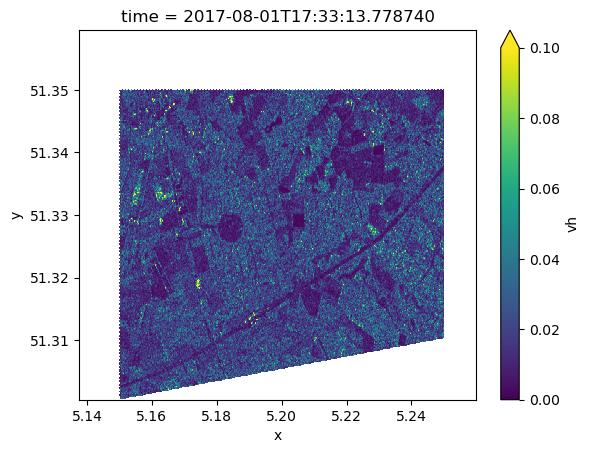

In [13]:
ds.vh[0].plot.imshow(vmin=0, vmax=0.1)

(Radar_Vegetation_index_RVI)=
## Radar Vegetation Index

Now that we have our geocoded GRD data, we can compute the vegetation indexes:
1. Radar Vegetation Index (RVI) by [Nasirzadehdizaji et al.](https://www.mdpi.com/2076-3417/9/4/655): $RVI = \frac{4\sigma^0_{VH}}{\sigma^0_{VV}+\sigma^0_{VH}}$

2. Dual-pol Radar Vegetation Index for GRD data (DpRVI) by [Bhogapurapu et al.](https://www.sciencedirect.com/science/article/pii/S0034425722000141): $DpRVI = \frac{q(q+3)}{(q+1)^2}$ where $q = \frac{\sigma^0_{VH}}{\sigma^0_{VV}}$

In [14]:
RVI = 4 * ds.vh / (ds.vv + ds.vh)

q = ds.vh / ds.vv
DpRVI = q * (q + 3) / (q + 1) ** 2

(Time_RVI)=
## Time Series Analysis

We were able to compute the indexes for a single step in time. However a single view is not enough to characterize the vegetation behaviour in the long term.  
Therefore, we have to do the same processing for all the products we selected via the STAC API.

In [15]:
from joblib import Parallel, delayed


def preprocess_grd(grd_path, bbox):
    # Data Access
    dt = xr.open_datatree(grd_path, engine="zarr", chunks="auto")
    t = np.datetime64(dt.attrs["stac_discovery"]["properties"]["datetime"][:-2], "ns")

    group_VH = [x for x in dt.children if "VH" in x][0]
    grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
    group_VV = [x for x in dt.children if "VV" in x][0]
    grd["vv"] = dt[group_VV].measurements.to_dataset().grd

    # Spatial Slicing
    gcps = dt[group_VH].conditions.gcp.to_dataset()[["latitude", "longitude"]]
    mask = (
        (gcps.latitude < bbox[3])
        & (gcps.latitude > bbox[1])
        & (gcps.longitude < bbox[2])
        & (gcps.longitude > bbox[0])
    )
    idx = np.where(mask == 1)
    if len(idx[0]) == 0 or len(idx[1]) == 0:
        return None
    azimuth_time_slice, ground_range_slice = build_slice(mask.shape, idx)

    gcps_crop = gcps.isel(
        dict(azimuth_time=azimuth_time_slice, ground_range=ground_range_slice)
    )

    azimuth_time_min = gcps_crop.azimuth_time.min().values
    azimuth_time_max = gcps_crop.azimuth_time.max().values

    ground_range_min = gcps_crop.ground_range.min().values
    ground_range_max = gcps_crop.ground_range.max().values

    grd_crop = grd.sel(
        dict(
            azimuth_time=slice(azimuth_time_min, azimuth_time_max),
            ground_range=slice(ground_range_min, ground_range_max),
        )
    )

    gcps_crop_interp = gcps_crop.interp_like(grd_crop)
    grd_crop = grd_crop.assign_coords(
        {"latitude": gcps_crop_interp.latitude, "longitude": gcps_crop_interp.longitude}
    )
    mask_2 = (
        (gcps_crop_interp.latitude < bbox[3])
        & (gcps_crop_interp.latitude > bbox[1])
        & (gcps_crop_interp.longitude < bbox[2])
        & (gcps_crop_interp.longitude > bbox[0])
    )
    grd_crop = grd_crop.where(mask_2.compute(), drop=True)

    # Calibration
    sigma_lut = dt[group_VH].quality.calibration.sigma_nought.interp_like(
        grd_crop, method="linear"
    )
    sigma_0 = (abs(grd_crop.astype(np.float32)) ** 2) / (sigma_lut**2)
    sigma_0 = sigma_0.assign_coords(time=t)

    return [
        sigma_0,
        (
            np.min(sigma_0.latitude.values).item(),
            np.max(sigma_0.latitude.values).item(),
        ),
        (
            np.min(sigma_0.longitude.values).item(),
            np.max(sigma_0.longitude.values).item(),
        ),
    ]


grd_products = Parallel(n_jobs=-1)(
    delayed(preprocess_grd)(grd_path, bbox) for grd_path in grd_paths
)

Extract min/max values for the longitude and latitude to build a common regular grid

In [16]:
min_lat = np.min([i[1][0] for i in grd_products if i is not None])
max_lat = np.max([i[1][1] for i in grd_products if i is not None])

min_lon = np.min([i[2][0] for i in grd_products if i is not None])
max_lon = np.max([i[2][1] for i in grd_products if i is not None])

grid_x_regular, grid_y_regular = create_regular_grid(
    min_lon, max_lon, min_lat, max_lat, 0.0001
)

Geocode and combine the time series of sigma nought data into a single datacube:

In [17]:
grd_products_geocoded = Parallel(n_jobs=-1)(
    delayed(geocode_grd)(grd_product[0], grid_x_regular, grid_y_regular)
    for grd_product in grd_products
    if grd_product is not None
)
sigma_0_series = xr.concat(grd_products_geocoded, dim="time").sortby("time")

/opt/conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Combine data from adjacent GRD scenes for the same day (coming from different Zarr products):

In [18]:
sigma_0_series = (
    sigma_0_series.groupby("time.date").max("time").rename(dict(date="time"))
)
sigma_0_series

<xarray.Dataset> Size: 762MB
Dimensions:  (time: 16, y: 1693, x: 1757)
Coordinates:
  * time     (time) object 128B 2017-05-03 2017-05-09 ... 2017-07-26 2017-08-01
  * y        (y) float32 7kB 51.19 51.19 51.19 51.19 ... 51.36 51.36 51.36 51.36
  * x        (x) float32 7kB 5.112 5.112 5.112 5.112 ... 5.287 5.287 5.287 5.288
Data variables:
    vh       (time, y, x) float64 381MB nan nan nan nan nan ... nan nan nan nan
    vv       (time, y, x) float64 381MB nan nan nan nan nan ... nan nan nan nan

In [19]:
sigma_0_series = sigma_0_series.where(~np.isnan(sigma_0_series), drop=True)

Store the result locally, so that in case the Kernel crashes it will be possible to start again from the next cell, skipping the pre-processing steps.

In [20]:
sigma_0_series["time"] = [pd.to_datetime(x) for x in sigma_0_series.time.values]
sigma_0_series.to_zarr("sigma_0_series.zarr")

In [21]:
import xarray as xr

sigma_0_series = xr.open_dataset("sigma_0_series.zarr", engine="zarr")

Compute the vegetation indexes:

In [22]:
ds = sigma_0_series

RVI = (4 * ds.vh) / (ds.vv + ds.vh)

q = ds.vh / ds.vv
DpRVI = q * (q + 3) / (q + 1) ** 2

(Agg_RVI)=
## Spatial Aggregation

A sample geoJSON file containing the field of three different crop fields boundaries provides us the location of interest to perform our analysis:

In [23]:
import geopandas as gpd

fields = gpd.read_file("./geojson/fields.geojson")
fields

,geometry
0,"POLYGON ((5.21152 51.29358, 5.21575 51.29391, ..."
1,"POLYGON ((5.18495 51.30253, 5.18685 51.29976, ..."
2,"POLYGON ((5.22471 51.33151, 5.22632 51.32867, ..."


Now we can use the Xvec library to aggregate our radar vegetation index values over the specific fields:

In [24]:
aggregated_DpRVI = DpRVI.xvec.zonal_stats(fields.geometry, x_coords="x", y_coords="y")
aggregated_RVI = RVI.xvec.zonal_stats(fields.geometry, x_coords="x", y_coords="y")

And finally plot the resulting time series. We will notice that the two variations of the radar vegetation index assume really similar values, where the main difference is that the DpRVI is scaled between 0 and 1, whereas the RVI is not.

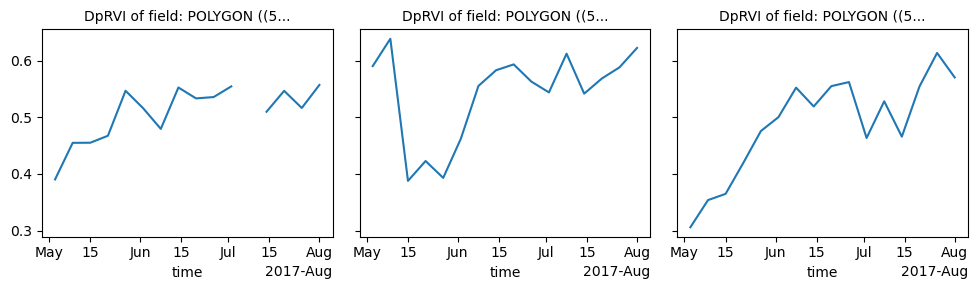

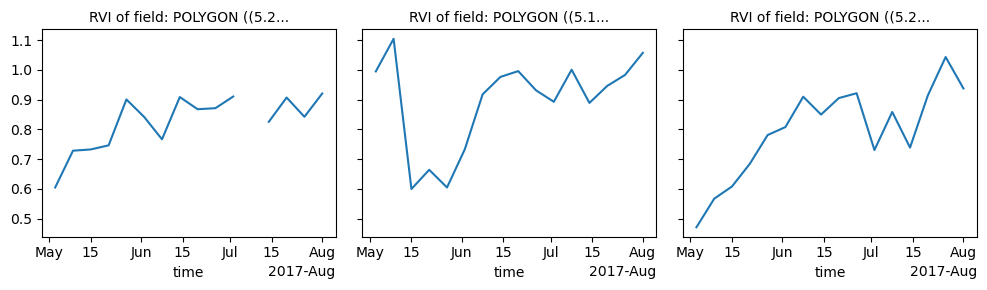

In [25]:
ax0 = aggregated_DpRVI.plot(col="geometry", col_wrap=3)
ax0.set_titles("DpRVI of field: {value}")
ax1 = aggregated_RVI.plot(col="geometry", col_wrap=3)
ax1.set_titles("RVI of field: {value}")

(Summary_RVI)=
## Summary

This notebook showed a complete Sentinel-1 GRD pipeline: from the data access to the final time series analysis.

**Some important remarks:**
- **Sentinel-1 GRD data has to be calibrated and geocoded before using it in this kind of analysis.**
- **This notebook proposes an efficient way to crop and geocode the data, which is highly relevant for small areas and long time series.**

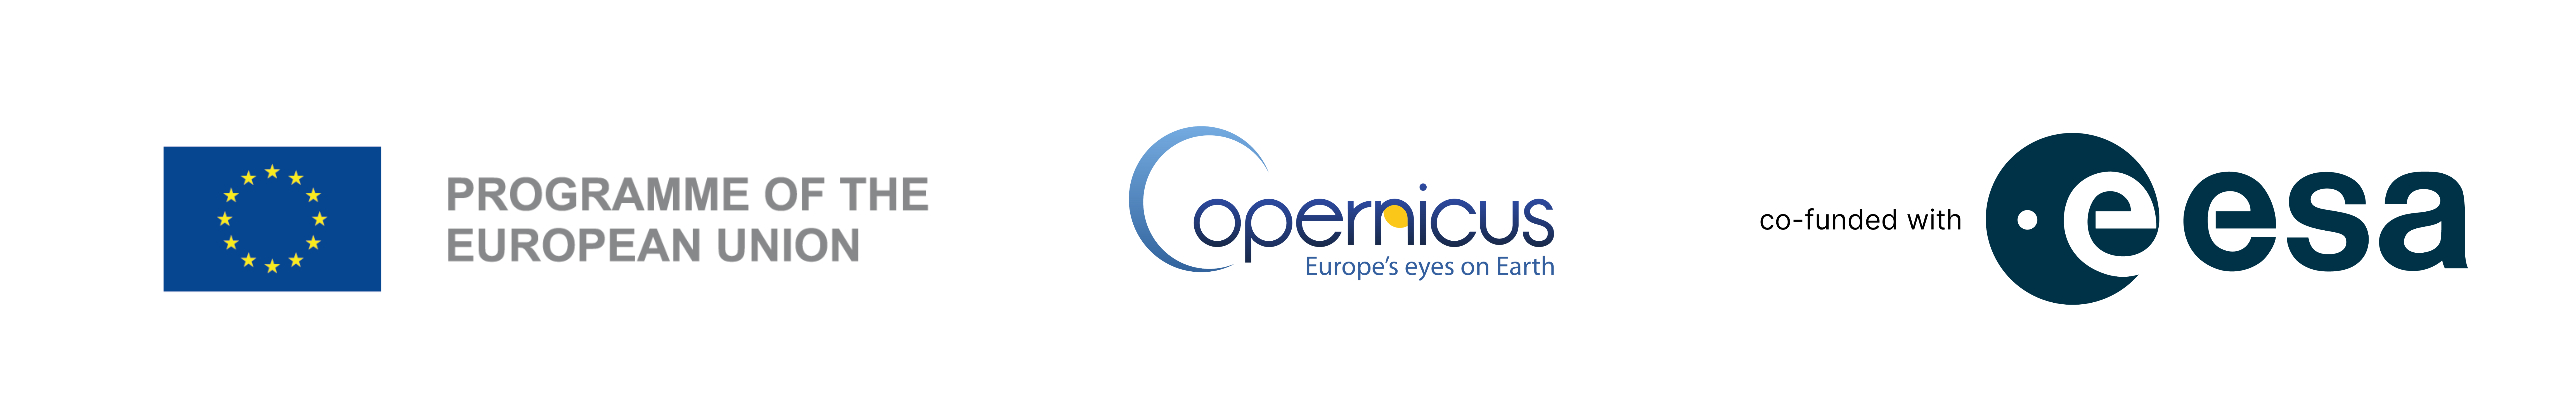